# Import Libraries

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load and Pre-Process data

In [125]:
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1,1)

X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

# Create DataFrame

In [126]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column
df['target'] = iris.target

# Optional: Add target names (Setosa, Versicolor, Virginica)
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Show the table
print(df.head(10))          # First 10 rows
print("\nShape:", df.shape)
print("\nColumn names:", df.columns.tolist())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
5       0 

# One-hot-encode labels

In [127]:
encoder = OneHotEncoder(sparse_output = False)
y_onehot = encoder.fit_transform(y)

# Train Test Split + Standardization

In [128]:
# First split: Train+Val vs Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)

# Second split: Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42  # 0.25 of 80% = 20% overall
)

# Standardization (fit only on train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 90 | Val: 30 | Test: 30


# Activation Functions

In [129]:
def relu(z):
    return np.maximum(0,z)
def relu_derivative(z):
    return (z>0).astype(float)
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# MLP Class with Backpropagation
MLP stands for Multi-Layer Perceptron. It is a type of artificial neural network used for classification and regression.

In your Iris flower project, the MLP learns to classify a flower into:

🌸 Setosa

🌸 Versicolor

🌸 Virginica

Network Look Like This

                 MLP Neural Network

Input Layer       Hidden Layer        Output Layer

Sepal Length ──┐

Sepal Width  ──┤

Petal Length ──┼──> 8 Neurons ──> 3 Neurons

Petal Width  ──┘
                        
                        ↓              ↓
                      ReLU          Softmax
                                      ↓
                            ┌─────────┼─────────┐
                          Setosa  Versicolor  Virginica


Backpropagation is the process of calculating how much each weight contributed to the prediction error and then using that information to improve the weights.

Forward propagation makes a prediction.
Backpropagation learns from the mistake.

MLP with Backpropagation is a neural network where forward propagation produces predictions, the loss function measures the error, and backpropagation calculates gradients to update the weights so the model becomes better at prediction over repeated training epochs.

In [130]:
class MLP:
    def __init__(self, input_size=4, hidden_size=8, output_size=3, lr=0.1):
        self.lr = lr
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        self.train_loss_history = []
        self.val_loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []
    
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    
    def compute_accuracy(self, y_true, y_pred):
        pred_labels = np.argmax(y_pred, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        return np.mean(pred_labels == true_labels) * 100
    
    def backward(self, X, y_true, y_pred):
        m = X.shape[0]
        
        dz2 = y_pred - y_true
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        
        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
    
    def train(self, X_train, y_train, X_val, y_val, epochs=1000):
        for epoch in range(epochs):
            # ----- Training -----
            y_pred_train = self.forward(X_train)
            train_loss = self.compute_loss(y_train, y_pred_train)
            train_acc = self.compute_accuracy(y_train, y_pred_train)
            
            self.backward(X_train, y_train, y_pred_train)
            
            # ----- Validation -----
            y_pred_val = self.forward(X_val)
            val_loss = self.compute_loss(y_val, y_pred_val)
            val_acc = self.compute_accuracy(y_val, y_pred_val)
            
            # Store history
            self.train_loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)
            self.train_acc_history.append(train_acc)
            self.val_acc_history.append(val_acc)
            
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1:4d} | "
                      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                      f"Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")
    
    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

# Train the Model

In [131]:
model = MLP(input_size=4, hidden_size=10, output_size=3, lr=0.1)
model.train(X_train, y_train, X_val, y_val, epochs=1000)

Epoch  100 | Train Loss: 0.1930 | Val Loss: 0.2065 | Train Acc: 95.6% | Val Acc: 93.3%
Epoch  200 | Train Loss: 0.1124 | Val Loss: 0.1209 | Train Acc: 96.7% | Val Acc: 93.3%
Epoch  300 | Train Loss: 0.0827 | Val Loss: 0.0925 | Train Acc: 97.8% | Val Acc: 96.7%
Epoch  400 | Train Loss: 0.0657 | Val Loss: 0.0800 | Train Acc: 97.8% | Val Acc: 96.7%
Epoch  500 | Train Loss: 0.0550 | Val Loss: 0.0741 | Train Acc: 97.8% | Val Acc: 96.7%
Epoch  600 | Train Loss: 0.0476 | Val Loss: 0.0723 | Train Acc: 98.9% | Val Acc: 96.7%
Epoch  700 | Train Loss: 0.0421 | Val Loss: 0.0726 | Train Acc: 98.9% | Val Acc: 96.7%
Epoch  800 | Train Loss: 0.0378 | Val Loss: 0.0743 | Train Acc: 98.9% | Val Acc: 96.7%
Epoch  900 | Train Loss: 0.0342 | Val Loss: 0.0766 | Train Acc: 98.9% | Val Acc: 96.7%
Epoch 1000 | Train Loss: 0.0313 | Val Loss: 0.0792 | Train Acc: 98.9% | Val Acc: 96.7%


# Evaluation

In [132]:
train_acc = model.compute_accuracy(y_train, model.forward(X_train))
val_acc   = model.compute_accuracy(y_val, model.forward(X_val))
test_acc  = model.compute_accuracy(y_test, model.forward(X_test))

print("\nFinal Results ")
print(f"Train Accuracy : {train_acc:.2f}%")
print(f"Val Accuracy   : {val_acc:.2f}%")
print(f"Test Accuracy  : {test_acc:.2f}%")


Final Results 
Train Accuracy : 98.89%
Val Accuracy   : 96.67%
Test Accuracy  : 96.67%


# Plots

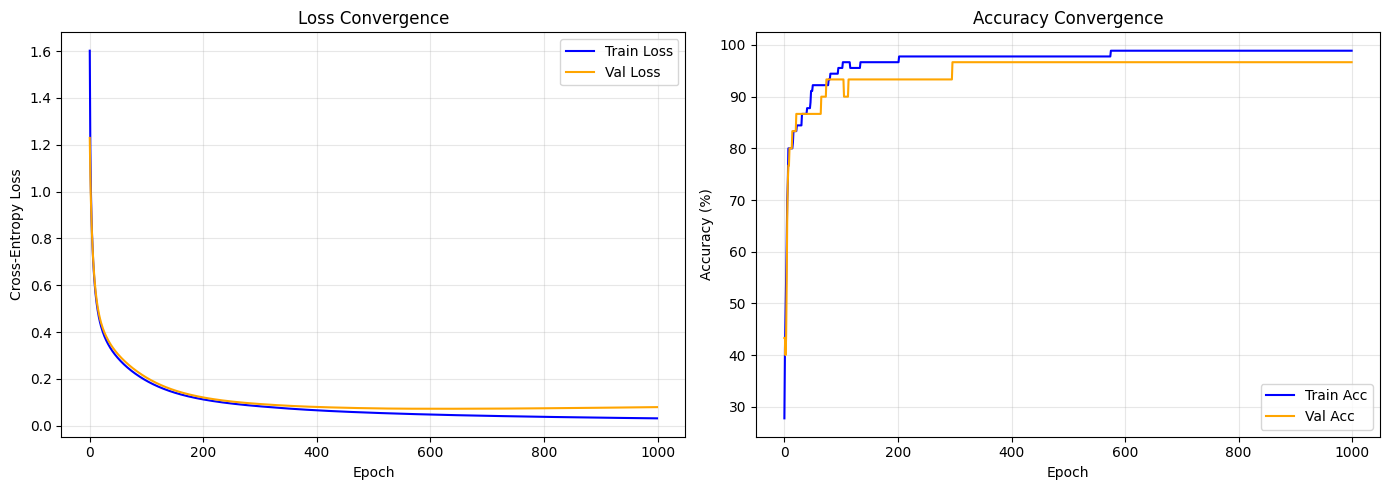

In [133]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(model.train_loss_history, label='Train Loss', color='blue')
ax1.plot(model.val_loss_history, label='Val Loss', color='orange')
ax1.set_title("Loss Convergence")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(model.train_acc_history, label='Train Acc', color='blue')
ax2.plot(model.val_acc_history, label='Val Acc', color='orange')
ax2.set_title("Accuracy Convergence")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Prediction function with confidence

In [134]:
def predict_with_confidence(model, X):
    """
    Returns predictions and confidence scores for each sample

    Parameters:
    - model: trained MLP model
    - X: input features (already scaled)

    Returns:
    - predictions: class labels (0, 1, 2)
    - confidences: confidence percentage for each prediction
    - all_probs: full probability distribution for each sample
    """

    # Get probabilities from model
    probs = model.forward(X)

    # Predicted class based on highest probability
    predictions = np.argmax(probs, axis=1)

    # Confidence score (highest probability)
    confidences = np.max(probs, axis=1) * 100  # convert to percentage

    return predictions, confidences, probs


# Predictions on test data

predictions, confidences, all_probs = predict_with_confidence(model, X_test)

print("\nPredictions with Confidence Scores:")
print("=" * 70)

species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

for i in range(min(10, len(predictions))):  # show first 10 samples
    pred_species = species_map[predictions[i]]
    true_species = species_map[np.argmax(y_test[i])]

    print(f"\nSample {i+1}:")
    print(f"  Prediction: {pred_species}")
    print(f"  Confidence: {confidences[i]:.2f}%")
    print(f"  Actual: {true_species}")
    print(f"  Class Probabilities:")
    print(f"    setosa: {all_probs[i][0]:.3f}")
    print(f"    versicolor: {all_probs[i][1]:.3f}")
    print(f"    virginica: {all_probs[i][2]:.3f}")
    print("-" * 50)


Predictions with Confidence Scores:

Sample 1:
  Prediction: setosa
  Confidence: 99.99%
  Actual: setosa
  Class Probabilities:
    setosa: 1.000
    versicolor: 0.000
    virginica: 0.000
--------------------------------------------------

Sample 2:
  Prediction: virginica
  Confidence: 84.15%
  Actual: virginica
  Class Probabilities:
    setosa: 0.000
    versicolor: 0.158
    virginica: 0.841
--------------------------------------------------

Sample 3:
  Prediction: versicolor
  Confidence: 95.69%
  Actual: versicolor
  Class Probabilities:
    setosa: 0.043
    versicolor: 0.957
    virginica: 0.000
--------------------------------------------------

Sample 4:
  Prediction: versicolor
  Confidence: 99.37%
  Actual: versicolor
  Class Probabilities:
    setosa: 0.006
    versicolor: 0.994
    virginica: 0.000
--------------------------------------------------

Sample 5:
  Prediction: setosa
  Confidence: 100.00%
  Actual: setosa
  Class Probabilities:
    setosa: 1.000
    versi

# detailed evaluation with confidence

In [135]:
def detailed_evaluation_with_confidence(model, X_data, y_data, dataset_name="Dataset"):
    """Detailed evaluation with confidence"""

    predictions, confidences, probs = predict_with_confidence(model, X_data)
    true_labels = np.argmax(y_data, axis=1)

    correct = (predictions == true_labels)
    accuracy = np.mean(correct) * 100

    print(f"\n{dataset_name} Evaluation:")
    print("=" * 60)
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Average Confidence: {np.mean(confidences):.2f}%")
    print(f"Minimum Confidence: {np.min(confidences):.2f}%")
    print(f"Maximum Confidence: {np.max(confidences):.2f}%")

    # Show misclassified samples
    misclassified = ~correct
    if np.any(misclassified):
        print("\nMisclassified Samples:")
        print("-" * 60)

        species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

        for i in np.where(misclassified)[0][:5]:  # show first 5
            print(f"Sample {i+1}:")
            print(f"  Predicted: {species_map[predictions[i]]} (Confidence: {confidences[i]:.2f}%)")
            print(f"  Actual: {species_map[true_labels[i]]}")


# Evaluate on all datasets

print("\n" + "="*70)
print("Complete Evaluation with Confidence")
print("="*70)

detailed_evaluation_with_confidence(model, X_train, y_train, "Training Set")
detailed_evaluation_with_confidence(model, X_val, y_val, "Validation Set")
detailed_evaluation_with_confidence(model, X_test, y_test, "Test Set")


Complete Evaluation with Confidence

Training Set Evaluation:
Accuracy: 98.89%
Average Confidence: 97.52%
Minimum Confidence: 56.55%
Maximum Confidence: 100.00%

Misclassified Samples:
------------------------------------------------------------
Sample 27:
  Predicted: versicolor (Confidence: 56.55%)
  Actual: virginica

Validation Set Evaluation:
Accuracy: 96.67%
Average Confidence: 96.91%
Minimum Confidence: 59.60%
Maximum Confidence: 100.00%

Misclassified Samples:
------------------------------------------------------------
Sample 6:
  Predicted: virginica (Confidence: 78.55%)
  Actual: versicolor

Test Set Evaluation:
Accuracy: 96.67%
Average Confidence: 96.02%
Minimum Confidence: 72.94%
Maximum Confidence: 100.00%

Misclassified Samples:
------------------------------------------------------------
Sample 26:
  Predicted: virginica (Confidence: 72.94%)
  Actual: versicolor


# Predictions on New Data

In [136]:
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],   # should be setosa
    [6.5, 3.0, 5.2, 2.0],   # should be virginica
    [5.9, 3.0, 4.2, 1.5],   # should be versicolor
    [4.8, 3.4, 1.6, 0.2],   # should be setosa
    [7.2, 3.2, 6.0, 1.8],   # should be virginica
])

# Scale the data (must use the same scaler!)

new_samples_scaled = scaler.transform(new_samples)

# Prediction with confidence

new_predictions, new_confidences, new_probs = predict_with_confidence(
    model, new_samples_scaled
)

# Display results

species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

print("\n" + "=" * 70)
print("Predictions on New Data (Real-world Samples)")
print("=" * 70)

for i in range(len(new_samples)):
    pred_species = species_map[new_predictions[i]]

    print(f"\nSample {i+1}: {new_samples[i]}")
    print(f"  → Prediction: {pred_species}")
    print(f"  → Confidence: {new_confidences[i]:.2f}%")
    print(f"  → Class Probabilities:")
    print(f"      setosa: {new_probs[i][0]:.3f}")
    print(f"      versicolor: {new_probs[i][1]:.3f}")
    print(f"      virginica: {new_probs[i][2]:.3f}")


Predictions on New Data (Real-world Samples)

Sample 1: [5.1 3.5 1.4 0.2]
  → Prediction: setosa
  → Confidence: 99.99%
  → Class Probabilities:
      setosa: 1.000
      versicolor: 0.000
      virginica: 0.000

Sample 2: [6.5 3.  5.2 2. ]
  → Prediction: virginica
  → Confidence: 99.45%
  → Class Probabilities:
      setosa: 0.000
      versicolor: 0.005
      virginica: 0.995

Sample 3: [5.9 3.  4.2 1.5]
  → Prediction: versicolor
  → Confidence: 97.85%
  → Class Probabilities:
      setosa: 0.004
      versicolor: 0.979
      virginica: 0.018

Sample 4: [4.8 3.4 1.6 0.2]
  → Prediction: setosa
  → Confidence: 99.99%
  → Class Probabilities:
      setosa: 1.000
      versicolor: 0.000
      virginica: 0.000

Sample 5: [7.2 3.2 6.  1.8]
  → Prediction: virginica
  → Confidence: 99.79%
  → Class Probabilities:
      setosa: 0.000
      versicolor: 0.002
      virginica: 0.998


# prediction (takes user input)

In [137]:
def predict_flower_interactive():
    """Interactive prediction - takes user input"""

    print("\n" + "="*60)
    print("Iris Flower Prediction Tool")
    print("="*60)
    print("\nEnter flower measurements:")

    try:
        sepal_length = float(input("  Sepal length (cm): "))
        sepal_width = float(input("  Sepal width (cm): "))
        petal_length = float(input("  Petal length (cm): "))
        petal_width = float(input("  Petal width (cm): "))

        # Create sample and scale
        sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
        sample_scaled = scaler.transform(sample)

        # Prediction
        pred, conf, probs = predict_with_confidence(model, sample_scaled)

        # Show result
        species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

        print(f"\n{'='*60}")
        print(f"Prediction: {species_map[pred[0]]}")
        print(f"Confidence: {conf[0]:.2f}%")

        print(f"\nClass Probabilities:")
        print(f"  Setosa: {probs[0][0]:.3f} ({probs[0][0]*100:.1f}%)")
        print(f"  Versicolor: {probs[0][1]:.3f} ({probs[0][1]*100:.1f}%)")
        print(f"  Virginica: {probs[0][2]:.3f} ({probs[0][2]*100:.1f}%)")
        print("="*60)

    except ValueError:
        print("Please enter valid numeric values!")


# Uncomment the line below to run user input mode
predict_flower_interactive()


Iris Flower Prediction Tool

Enter flower measurements:


  Sepal length (cm):  5.9
  Sepal width (cm):  3.0
  Petal length (cm):  4.2 
  Petal width (cm):  1.5



Prediction: versicolor
Confidence: 97.85%

Class Probabilities:
  Setosa: 0.004 (0.4%)
  Versicolor: 0.979 (97.9%)
  Virginica: 0.018 (1.8%)


# Confidence Visualization

/tmp/ipykernel_58/2196083377.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


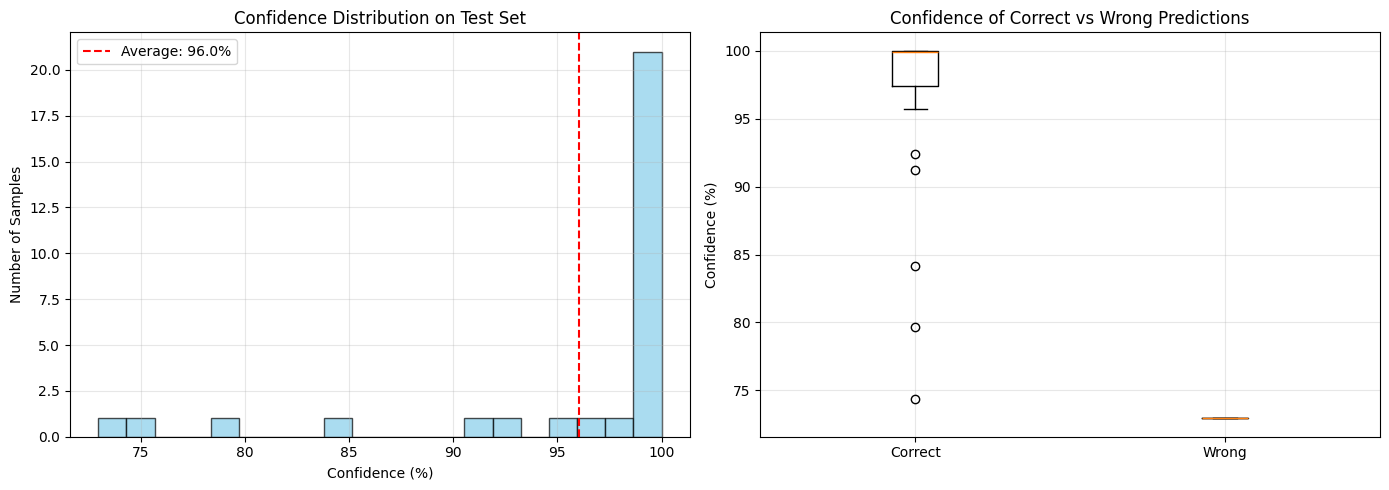

In [138]:
plt.figure(figsize=(14, 5))

# 1. Confidence Distribution

plt.subplot(1, 2, 1)

plt.hist(
    confidences,
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Confidence (%)')
plt.ylabel('Number of Samples')
plt.title('Confidence Distribution on Test Set')

plt.axvline(
    np.mean(confidences),
    color='red',
    linestyle='--',
    label=f'Average: {np.mean(confidences):.1f}%'
)

plt.legend()
plt.grid(True, alpha=0.3)


# 2. Confidence of Correct vs Wrong Predictions

plt.subplot(1, 2, 2)

true_labels = np.argmax(y_test, axis=1)

correct = (predictions == true_labels)

correct_conf = confidences[correct]
wrong_conf = confidences[~correct]

plt.boxplot(
    [correct_conf, wrong_conf],
    labels=['Correct', 'Wrong']
)

plt.ylabel('Confidence (%)')
plt.title('Confidence of Correct vs Wrong Predictions')

plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()